In [ ]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

In [2]:
# Load averaged results
date_one_to_one_gaussian = "03080904"
with open(f"../Results_averaged/optuna_lorenz63_qrc_gaussian_results_{date_one_to_one_gaussian}_combined.pkl", "rb") as f:
    data_one_to_one_gaussian = pickle.load(f)

date_fill_gaussian = "03081311"
with open(f"../Results_averaged/optuna_lorenz63_qrc_gaussian_results_{date_fill_gaussian}_combined.pkl", "rb") as f:
    data_fill_gaussian = pickle.load(f)

date_dense_gaussian = "03080905"
with open(f"../Results_averaged/optuna_lorenz63_qrc_gaussian_results_{date_dense_gaussian}_combined.pkl", "rb") as f:
    data_dense_gaussian = pickle.load(f)

date_one_to_one_spin = "03081326"
with open(f"../Results_averaged/optuna_lorenz63_qrc_tilted_tfim_results_{date_one_to_one_spin}_combined.pkl", "rb") as f:
    data_one_to_one_spin = pickle.load(f)

date_fill_spin = "03081329"
with open(f"../Results_averaged/optuna_lorenz63_qrc_tilted_tfim_results_{date_fill_spin}_combined.pkl", "rb") as f:
    data_fill_spin = pickle.load(f)

date_dense_spin = "03081328"
with open(f"../Results_averaged/optuna_lorenz63_qrc_tilted_tfim_results_{date_dense_spin}_combined.pkl", "rb") as f:
    data_dense_spin = pickle.load(f)

In [3]:
df2_one_to_one_gaussian = pd.DataFrame(data_one_to_one_gaussian)
df2_fill_gaussian = pd.DataFrame(data_fill_gaussian)
df2_dense_gaussian = pd.DataFrame(data_dense_gaussian)

df2_one_to_one_spin = pd.DataFrame(data_one_to_one_spin)
df2_fill_spin = pd.DataFrame(data_fill_spin)
df2_dense_spin = pd.DataFrame(data_dense_spin)

In [4]:
models_data = [
    ("DV-QRC", [
        ("Local", df2_one_to_one_spin),
        ("Clustered", df2_fill_spin),
        ("Global", df2_dense_spin)
    ]),
    ("CV-QRC", [
        ("Local", df2_one_to_one_gaussian),
        ("Clustered", df2_fill_gaussian),
        ("Global", df2_dense_gaussian)
    ])
]

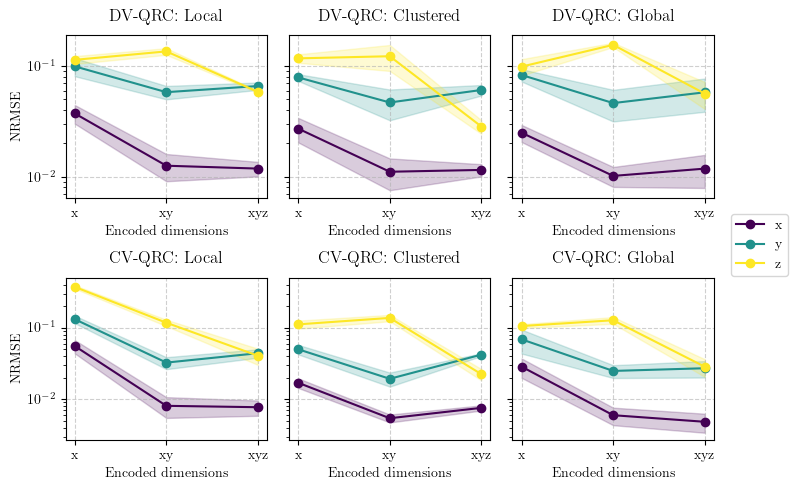

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Assume models_data is defined as in your prompt

# 1. Find all unique targets across all DataFrames to ensure consistent coloring
all_targets = set()
for model_name, experiments in models_data:
    for exp_name, exp_df in experiments:
        if 'target' in exp_df.columns:
            all_targets.update(exp_df['target'].dropna().unique())

# Remove 'all_1' from the targets list so it doesn't get assigned a color
all_targets.discard("all_1")
            
sorted_targets = sorted(list(all_targets))

# 2. Generate consistent colors from the viridis colormap
colors = cm.viridis(np.linspace(0, 1, len(sorted_targets)))
target_color_map = {target: color for target, color in zip(sorted_targets, colors)}

# 3. Create a 2 row, 3 column figure, sharing y-axis across rows
fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharey='row')
legend_handles = {}

# 4. Loop through the rows (Models) and columns (Experiments)
for row_idx, (model_name, experiments) in enumerate(models_data):
    for col_idx, (exp_name, exp_df) in enumerate(experiments):
        ax = axes[row_idx, col_idx]
        
        # Drop rows where mean or std is NaN
        plot_df = exp_df.dropna(subset=['best_score_mean', 'best_score_std']).copy()
        
        if plot_df.empty:
            ax.set_title(f"{model_name}: {exp_name}\n(No data)")
            continue
            
        targets_in_df = sorted(plot_df['target'].unique())
        anything_plotted_in_ax = False
        
        # Loop through each target to plot lines and error bands
        for target in targets_in_df:
            # Skip the 'all_1' target during plotting
            if target == "all_1":
                continue
                
            target_data = plot_df[plot_df['target'] == target].sort_values(by='d')
            
            if target_data.empty:
                continue
                
            x = target_data['d']
            y = target_data['best_score_mean']
            std = target_data['best_score_std']
            
            color = target_color_map[target]
            
            # Plot the mean line and fill the standard deviation
            line = ax.plot(x, y, marker='o', label=str(target), color=color)
            ax.fill_between(x, y - std, y + std, color=color, alpha=0.2)
            
            # Save the line handle for the master legend
            if target not in legend_handles:
                legend_handles[target] = line[0]
                
            anything_plotted_in_ax = True
            
        # 5. Format the specific subplot
        if anything_plotted_in_ax:
            ax.set_title(f"{model_name}: {exp_name}", pad=10)
            ax.set_xlabel("Encoded dimensions")
            ax.set_yscale('log')
            ax.grid(True, linestyle='--', alpha=0.6)
            
            # ---> ADDED: Hardcode the x-axis ticks and assign the string labels
            ax.set_xticks([1, 2, 3])
            ax.set_xticklabels(["x", "xy", "xyz"])
            
            # Set y-labels ONLY on the far left column
            if col_idx == 0:
                ax.set_ylabel("NRMSE")

# 6. Add the master legend and adjust layout
if legend_handles:
    # Dictionary to rename specific targets for the legend
    legend_rename_map = {
        "x_1": "x",
        "y_1": "y",
        "z_1": "z"
    }

    sorted_keys = sorted(legend_handles.keys())
    handles = [legend_handles[t] for t in sorted_keys]
    
    # Apply the renaming map, default to the original target string if not in the map
    labels = [legend_rename_map.get(str(t), str(t)) for t in sorted_keys]
    
    # Place legend to the right of the subplots
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.00, 0.5))
    
    # Compress subplots slightly to the left to leave room (10%) for the legend
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.savefig("../Plots/lorenz_encoding_comparison.pdf", bbox_inches='tight')
    plt.show()
else:
    plt.close(fig)
    print("No valid data found to plot.")

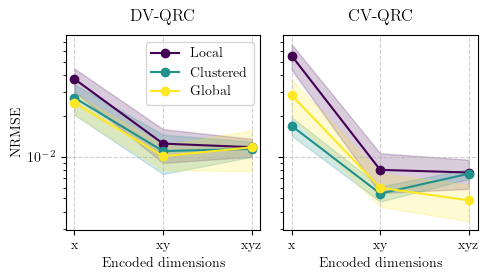

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Assume models_data is defined as in your prompt
# Format expected: [("spin", [("local", df), ...]), ("gaussian", [("local", df), ...])]

# 1. Find all unique experiment names (encoding methods) to ensure consistent coloring
all_experiments = []
for model_name, experiments in models_data:
    for exp_name, exp_df in experiments:
        if exp_name not in all_experiments:
            all_experiments.append(exp_name)

# 2. Generate consistent colors from the viridis colormap based on encoding method
colors = cm.viridis(np.linspace(0, 1, len(all_experiments)))
exp_color_map = {exp: color for exp, color in zip(all_experiments, colors)}

# 3. Create a 1 row, 2 column figure (left for spin, right for gaussian)
fig, axes = plt.subplots(1, 2, figsize=(5, 2.9), sharey=True)
legend_handles = {}

# 4. Loop through the Models (side-by-side subplots)
for ax_idx, (model_name, experiments) in enumerate(models_data):
    ax = axes[ax_idx] 
    
    anything_plotted_in_ax = False
    
    # Loop through the experiments
    for exp_name, exp_df in experiments:
        
        # Strictly filter for the 'x_1' target and drop NaNs
        plot_df = exp_df[exp_df['target'] == 'x_1'].dropna(subset=['best_score_mean', 'best_score_std']).copy()
        
        if plot_df.empty:
            continue
            
        # Ensure data is sorted by the x-axis dimension
        target_data = plot_df.sort_values(by='d')
        
        x = target_data['d']
        y = target_data['best_score_mean']
        std = target_data['best_score_std']
        
        color = exp_color_map[exp_name]
        
        # Plot the mean line and fill the standard deviation for this encoding method
        line = ax.plot(x, y, marker='o', label=exp_name, color=color)
        ax.fill_between(x, y - std, y + std, color=color, alpha=0.2)
        
        # Save the line handle for the master legend
        if exp_name not in legend_handles:
            legend_handles[exp_name] = line[0]
            
        anything_plotted_in_ax = True
        
    # 5. Format the specific subplot
    if anything_plotted_in_ax:
        ax.set_title(f"{model_name}", pad=10)
        ax.set_yscale('log')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Hardcode the x-axis ticks and assign the string labels
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(["x", "xy", "xyz"])
        
        # Both subplots need the x-label in a side-by-side layout
        ax.set_xlabel("Encoded dimensions")
        
        # Only put the y-label on the left subplot (index 0)
        if ax_idx == 0:
            ax.set_ylabel("NRMSE")
    else:
        ax.set_title(f"{model_name}\n(No 'x_1' data)")

# 6. Add the master legend and adjust layout
if legend_handles:
    # Retain the exact order of the experiments as they were discovered
    handles = [legend_handles[exp] for exp in all_experiments if exp in legend_handles]
    labels = [exp for exp in all_experiments if exp in legend_handles]
    
    # Place legend INSIDE the left subplot (axes[0])
    # Using 'best' allows matplotlib to find a spot that avoids overlapping the lines
    axes[0].legend(handles, labels, loc='best')
    
    # Standard tight_layout
    plt.tight_layout()
    plt.savefig("../Plots/lorenz_x1_encoding_comparison.pdf", bbox_inches='tight')
    plt.show()
else:
    plt.close(fig)
    print("No valid 'x_1' data found to plot across any models.")